###Financial Bank Loan Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

Saving financial_loan_data_excel.csv to financial_loan_data_excel.csv


In [3]:
import pandas as pd

df = pd.read_csv("financial_loan_data_excel.csv")
df['issue_date'] = pd.to_datetime(df['issue_date'], format='%d-%m-%Y')
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], format='%d-%m-%Y')
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], format='%d-%m-%Y')
df['next_payment_date'] = pd.to_datetime(df['next_payment_date'], format='%d-%m-%Y')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


##METAdata of Data

In [5]:
print("No of Rows:",df.shape[0])  #row=0

No of Rows: 38576


In [6]:
print("No of Column:",df.shape[1])  #column=1

No of Column: 24


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

##DATA TYPE

In [8]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [9]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


##Total Loan Applications

In [10]:
total_loan_applications=df['id'].count()
print("Total Loan Application:",total_loan_applications)

Total Loan Application: 38576


#MTD Total Loan Applications:

I found the latest loan issue date, took its year and month, filtered the data for that month, counted how many loans were issued, and printed the total.

In [11]:
latest_issue_date = df['issue_date'].max()
# I found the most recent (maximum) date from the issue_date column

latest_year = latest_issue_date.year
# I extracted the year from that latest date

latest_month = latest_issue_date.month
# I extracted the month from that latest date

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]
# I filtered the data to keep only rows from that latest year and month

mtd_loan_applications = mtd_data['id'].count()
# I counted the total number of loan applications in that filtered data

print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")
# I printed the total loan applications for that month in a readable format


MTD Loan Applications (for December 2021): 4314


#Total Funded Amount

I added all the loan amounts to get the total money given as loans, converted that total into millions by dividing by 10,00,000, and printed it in a clean format with 2 decimal places and “M” to show millions.

In [12]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions=total_funded_amount/1000000
print("Total Funded Amount:${:.2f}M".format (total_funded_amount_millions))

Total Funded Amount:$435.76M


#MTD- Total Funded Amount
I first found the most recent loan issue date in the dataset. Then I took the
year and month from that date and filtered the data to keep only the loans issued in that same month. After that, I added all the loan amounts for those loans, converted the total into millions to make it easier to read, and finally printed the result.
:.2f means show the number with 2 digits after the decimal.




In [13]:
latest_issue_date = df['issue_date'].max()
# I found the most recent (maximum) date from the issue_date column

latest_year = latest_issue_date.year
# I extracted the year from that latest date

latest_month = latest_issue_date.month
# I extracted the month from that latest date

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]
# I filtered the data to keep only rows from the latest year and month

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
# I added all loan amounts from that filtered data

mtd_total_funded_amount_millions = mtd_total_funded_amount / 1000000
# I converted the amount into millions

print(f"MTD Total Funded Amount: ${mtd_total_funded_amount_millions:.2f}M")
# I printed the result in a clean format with 2 decimal places

MTD Total Funded Amount: $53.98M


#Total Amount Received
 I added all the payments received from loans, converted the total into millions, and printed the result.

In [14]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received / 1000000
print("Total Amount Received:${:.2f}M".format(total_amount_received_millions))

Total Amount Received:$473.07M


#MTD- Total  Amount Received
I first found the most recent loan issue date in the dataset. Then I extracted the year and month from that date and filtered the data to keep only the loans issued in that same month. After that, I added all the payments received from those loans to get the total amount received for that month. I then converted this total into millions to make the number easier to read and finally printed the result in a clean format with two decimal places.


In [15]:
latest_issue_date = df['issue_date'].max()
# I found the most recent (maximum) date from the issue_date column

latest_year = latest_issue_date.year
# I extracted the year from that latest date

latest_month = latest_issue_date.month
# I extracted the month from that latest date

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]
# I filtered the data to keep only rows from the latest year and month

mtd_total_amount_received = mtd_data['total_payment'].sum()
# I added all the total payments received from that filtered data

mtd_total_amount_received_millions = mtd_total_amount_received / 1000000
# I converted the amount into millions

print(f"MTD Total Amount Received: ${mtd_total_amount_received_millions:.2f}M")
# I printed the result in a clean format with 2 decimal places

MTD Total Amount Received: $58.07M


###Average Interest Rate
I calculated the average interest rate of all loans in the int_rate column using the mean function. This gives one value that represents the typical interest rate across all loans instead of looking at many individual rates. I then printed the result in a clear format with two decimal places and added the percentage symbol so it is easy to read and understand in reports or analysis.

In [16]:
average_interest_rate = df['int_rate'].mean()*100
print("Avg Int Rate: {:.2f}%".format(average_interest_rate))


Avg Int Rate: 12.05%


##Average Debt-to-Income Ratio(DTI)

In [17]:
average_dti = df['dti'].mean()*100
print("Avg DTI: {:.2f}%".format(average_dti))

Avg DTI: 13.33%


###GOOD LOAN METRICS
I first filtered the dataset to select only good loans, which are loans whose status is “Fully Paid” or “Current.” These loans are considered good because the borrower is either paying regularly or has already completed the payment. Then I calculated the total number of loan applications in the dataset and counted how many of those are good loans. After that, I calculated the total loan amount funded for these good loans and also the total amount received from them through payments. To make the numbers easier to read and present in reports or dashboards, I converted both totals into millions. Finally, I calculated the percentage of good loan applications compared to all loan applications, which helps understand the overall loan performance, and then printed all the results in a clear format.

In [18]:
# Good Loan Metrics

# Filter good loans (Fully Paid or Current)
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]
# isin() checks if loan_status is in the list -> these are GOOD LOANS

# Total loan applications
total_loan_applications = df['id'].count()
# count of ALL loan applications in the dataset

# Good loan metrics
good_loan_applications = good_loans['id'].count()
# count of ONLY GOOD LOAN applications

good_loan_funded_amount = good_loans['loan_amount'].sum()
# total loan amount funded for GOOD LOANS

good_loan_received = good_loans['total_payment'].sum()
# total amount RECEIVED from GOOD LOANS

# Convert to millions (to make numbers easier to read)
good_loan_funded_amount_millions = good_loan_funded_amount / 1_000_000
good_loan_received_millions = good_loan_received / 1_000_000

# Percentage of good loans
good_loan_percentage = (good_loan_applications / total_loan_applications) * 100
# percentage of GOOD LOANS out of ALL loans

# Print results
print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


# BAD Loan Metrics
I first filtered the dataset to keep only bad loans, which are loans whose status is “Charged Off.” These loans are considered bad because the borrower did not repay the loan properly. Then I counted the total number of loan applications in the dataset and also counted how many of those are bad loans. After that, I calculated the total loan amount that was funded for these bad loans and the total amount that was actually received from them through payments. To make the numbers easier to read and present in reports or dashboards, I converted both amounts into millions. Finally, I calculated the percentage of bad loan applications compared to all loan applications to understand how much of the total portfolio consists of bad loans, and then printed all the results in a clear format.


In [19]:
# Bad Loan Metrics

# Filter bad loans (Charged Off)
bad_loans = df[df['loan_status'].isin(["Charged Off"])]
# isin() checks if loan_status is "Charged Off" -> these are BAD LOANS

# Total loan applications
total_loan_applications = df['id'].count()
# count of ALL loan applications in the dataset

# Bad loan metrics
bad_loan_applications = bad_loans['id'].count()
# count of ONLY BAD LOAN applications

bad_loan_funded_amount = bad_loans['loan_amount'].sum()
# total loan amount funded for BAD LOANS

bad_loan_received = bad_loans['total_payment'].sum()
# total amount RECEIVED from BAD LOANS

# Convert to millions (to make numbers easier to read)
bad_loan_funded_amount_millions = bad_loan_funded_amount / 1_000_000
bad_loan_received_millions = bad_loan_received / 1_000_000

# Percentage of bad loans
bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100
# percentage of BAD LOANS out of ALL loans

# Print results
print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


###Monthly Trends by Issue Date for Total Funded Amount

In this analysis, I wanted to understand how the total loan amount funded changes over time on a monthly basis. To start, I imported the Matplotlib library, which is used for creating visualizations and charts in Python. Then I sorted the loan dataset using the issue_date column so that the records appear in the correct chronological order. After that, I created a new column called month_name by extracting the month and year from the issue_date using a date formatting function. This converts dates like 2021-01-15 into a more readable format such as Jan 2021, which makes the chart easier to understand.

Next, I grouped the dataset by this month_name column and calculated the total funded loan amount for each month by summing the values in the loan_amount column. Since these numbers can be very large, I divided the totals by 1,000,000 to convert them into millions, which makes the values easier to display and interpret in the chart.

After preparing the monthly data, I created a figure using Matplotlib and plotted the results. I used fill_between() to create a shaded area under the curve and plot() to draw the line that represents the monthly trend of funded loan amounts. This combination helps visually highlight how the loan funding increases or decreases over time. I also used a loop to display the exact funded amount value above each data point, which makes the chart more informative and easier to read.

Finally, I formatted the chart by adding a title, axis labels for month and funded amount, rotated month labels for better visibility, and grid lines to improve readability. The final visualization clearly shows the monthly trend of total funded loan amounts, which helps identify patterns, growth, or fluctuations in lending activity over time.

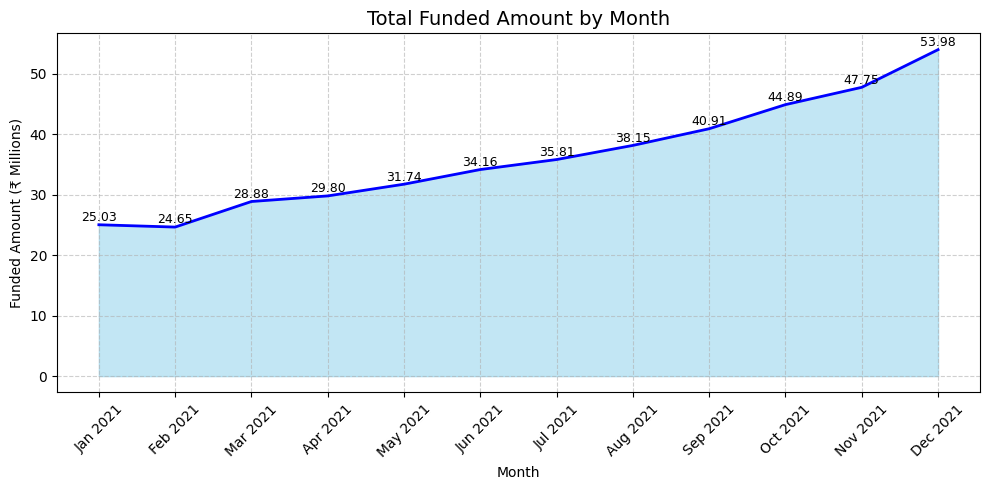

In [20]:
import matplotlib.pyplot as plt
# Import matplotlib library to create charts and visualize data

monthly_funded = (
    df.sort_values('issue_date')
    # Sort the dataset by issue_date so months appear in correct order

      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      # Create a new column called month_name
      # strftime() converts the date into readable text format
      # %b = short month name (Jan, Feb, Mar)
      # %Y = full year (2021, 2022)
      # Example: 2021-01-15 → Jan 2021

      .groupby('month_name', sort=False)['loan_amount']
      # Group the data by month_name and select loan_amount column

      .sum()
      # Calculate total loan amount funded in each month

      .div(1_000_000)
      # Convert funded amount into millions for easier reading

      .reset_index(name='loan_amount_millions')
      # Convert grouped result back into a dataframe
)

plt.figure(figsize=(10,5))
# Create chart canvas

x = range(len(monthly_funded))

plt.fill_between(
    x,
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)
# Create shaded area chart

plt.plot(
    x,
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)
# Draw line showing funded amount trend

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )
# Display value above each data point

plt.title('Total Funded Amount by Month', fontsize=14)
# Chart title

plt.xlabel('Month')
# X-axis label

plt.ylabel('Funded Amount (₹ Millions)')
# Y-axis label

plt.xticks(
    ticks=x,
    labels=monthly_funded['month_name'],
    rotation=45
)
# Show month labels on x-axis

plt.grid(True, linestyle='--', alpha=0.6)
# Add grid for better readability

plt.tight_layout()
# Adjust layout spacing

plt.show()
# Display chart

####### Monthly Trends by Issue Date for Total  Amount Received

In this analysis, I first imported the Matplotlib library to create visualizations. Then I sorted the dataset by issue_date to ensure the data appears in the correct chronological order. After that, I created a new column called month_name by extracting the month and year from the issue date so that the dates are easier to read in the chart. Next, I grouped the dataset by this month column and calculated the total amount received from loans each month using the total_payment column. I converted these values into millions to make the numbers easier to display and interpret. After preparing the monthly data, I created a chart using Matplotlib where I plotted the monthly received loan amount trend using both a line and a shaded area. I also displayed the exact value for each month above the chart points to make the visualization clearer. Finally, I formatted the chart by adding a title, axis labels, rotated month labels, and grid lines, which improves readability and helps analyze the monthly trend of loan repayments.


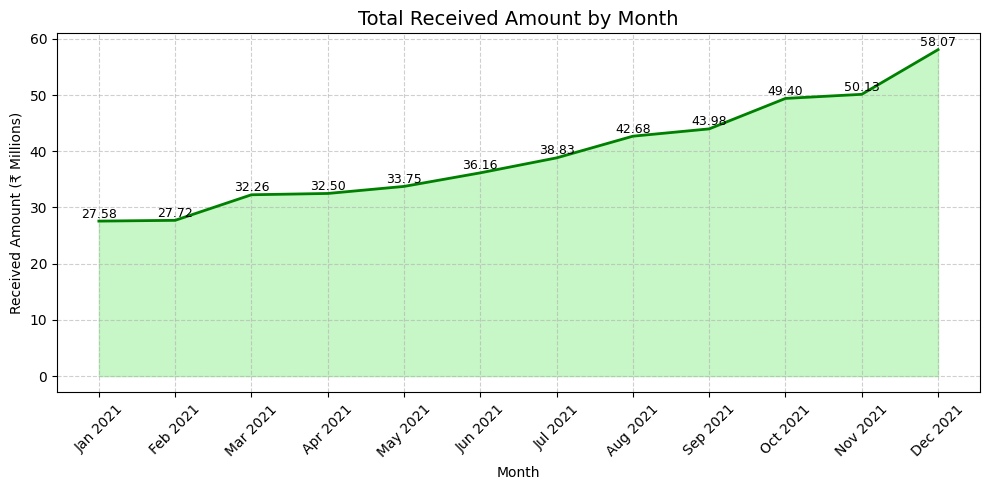

In [21]:
import matplotlib.pyplot as plt  # Import matplotlib library to create charts and visualizations

# Monthly Total Amount Received
monthly_received = (
    df.sort_values('issue_date')  # Sort the dataset by issue_date so months appear in correct order
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      # Create a new column called month_name (example: Jan 2021)

      .groupby('month_name', sort=False)['total_payment']
      # Group the data by month and select the total_payment column

      .sum()
      # Calculate the total amount received from loans in each month

      .div(1_000_000)
      # Convert the received amount into millions to make numbers easier to read

      .reset_index(name='received_amount_millions')
      # Convert the grouped result back into a dataframe
)

plt.figure(figsize=(10, 5))  # Create chart size (width=10, height=5)

plt.fill_between(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='lightgreen',
    alpha=0.5
)
# Create the shaded area under the line chart

plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)
# Draw the line showing the monthly received amount trend

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"{row['received_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )
# Loop through each row and display the received amount value above each point

plt.title('Total Received Amount by Month', fontsize=14)
# Add chart title

plt.xlabel('Month')
# Label for X-axis

plt.ylabel('Received Amount (₹ Millions)')
# Label for Y-axis

plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)
# Show month labels and rotate them for better readability

plt.grid(True, linestyle='--', alpha=0.6)
# Add grid lines to make the chart easier to read

plt.tight_layout()
# Adjust spacing so labels do not overlap

plt.show()
# Display the final chart


####### Monthly Trends by Issue Date for Total  Loan Application
This code analyzes the monthly trend of loan applications to understand how the number of loans issued changes over time. First, the dataset is sorted using the issue_date column so that the records appear in the correct chronological order. Then a new column called month_name is created by extracting the month and year from the issue date and converting it into a readable format such as Jan 2021, Feb 2021, and so on. After preparing the date format, the dataset is grouped by month, and the number of loan applications is calculated by counting the id column for each month. This produces a monthly summary showing how many loan applications were submitted during each period.

Once the data is prepared, a visualization is created using Matplotlib to clearly display the trend. A line chart is plotted to show how the number of loan applications changes from month to month, and a shaded area under the line is added to make the trend easier to interpret visually. The code also loops through each month and displays the exact number of loan applications above each data point, which helps make the chart more informative. Finally, the chart is formatted by adding a title, axis labels, rotated month labels, and grid lines to improve readability. This type of analysis is commonly used in financial analysis, banking, and business intelligence dashboards to track loan demand, identify patterns, and support data-driven decision-making.


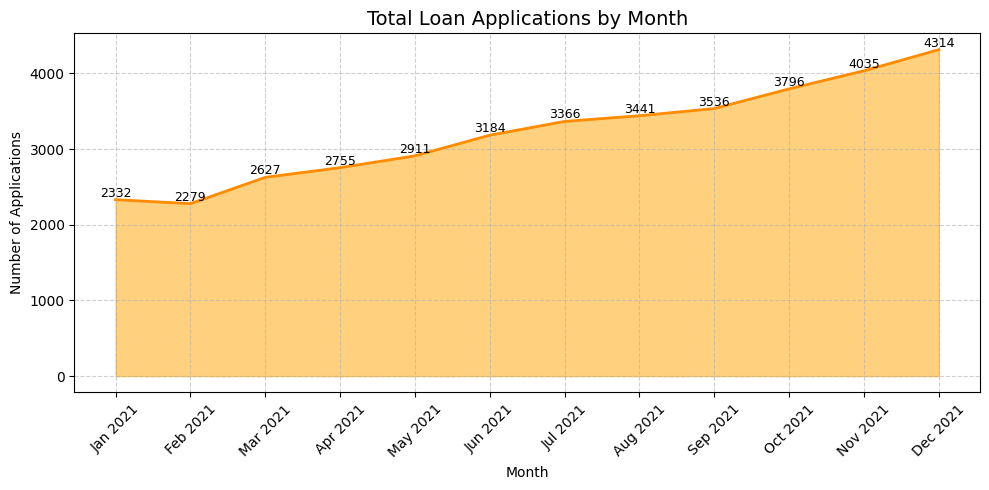

In [22]:
# Monthly Loan Applications Trend

monthly_applications = (
    df.sort_values('issue_date')
    # Sort dataset by issue_date so months appear in chronological order

    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    # Create a new column called month_name (example: Jan 2021)

    .groupby('month_name', sort=False)['id']
    # Group data by month and select the id column

    .count()
    # Count number of loan applications for each month

    .reset_index(name='loan_applications_count')
    # Convert grouped result into a dataframe and name the count column
)

plt.figure(figsize=(10, 5))
# Create chart canvas with width 10 and height 5

plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='orange',
    alpha=0.5
)
# Create shaded area under the chart

plt.plot(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='darkorange',
    linewidth=2
)
# Draw line showing monthly loan applications trend

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 0.5,
        f"{row['loan_applications_count']}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )
# Display the exact number of applications above each point

plt.title('Total Loan Applications by Month', fontsize=14)
# Add chart title

plt.xlabel('Month')
# Label for X-axis

plt.ylabel('Number of Applications')
# Label for Y-axis

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)
# Display month labels on x-axis and rotate for readability

plt.grid(True, linestyle='--', alpha=0.6)
# Add grid lines for easier interpretation

plt.tight_layout()
# Adjust spacing so labels don't overlap

plt.show()
# Display the final chart

#### Regional Analysis by State For Total Funded amount (Bar Chart): To identify regions with significant lending activity and assess regional disparities.
In this analysis, I performed a regional analysis of loan funding by state to understand how lending activity varies across different geographic regions. First, I grouped the dataset using the address_state column and calculated the total loan amount funded for each state using the loan_amount field. I then sorted the results and converted the funded values into thousands to make the numbers easier to read and display. After preparing the data, I created a horizontal bar chart using Matplotlib, where each bar represents a state and the length of the bar shows the total loan amount funded in that state. I also added the exact funded value next to each bar to make the chart more informative and easier to interpret. This analysis helps identify which states have the highest or lowest lending activity, allowing businesses or financial institutions to understand regional lending patterns and assess disparities in loan distribution across states.




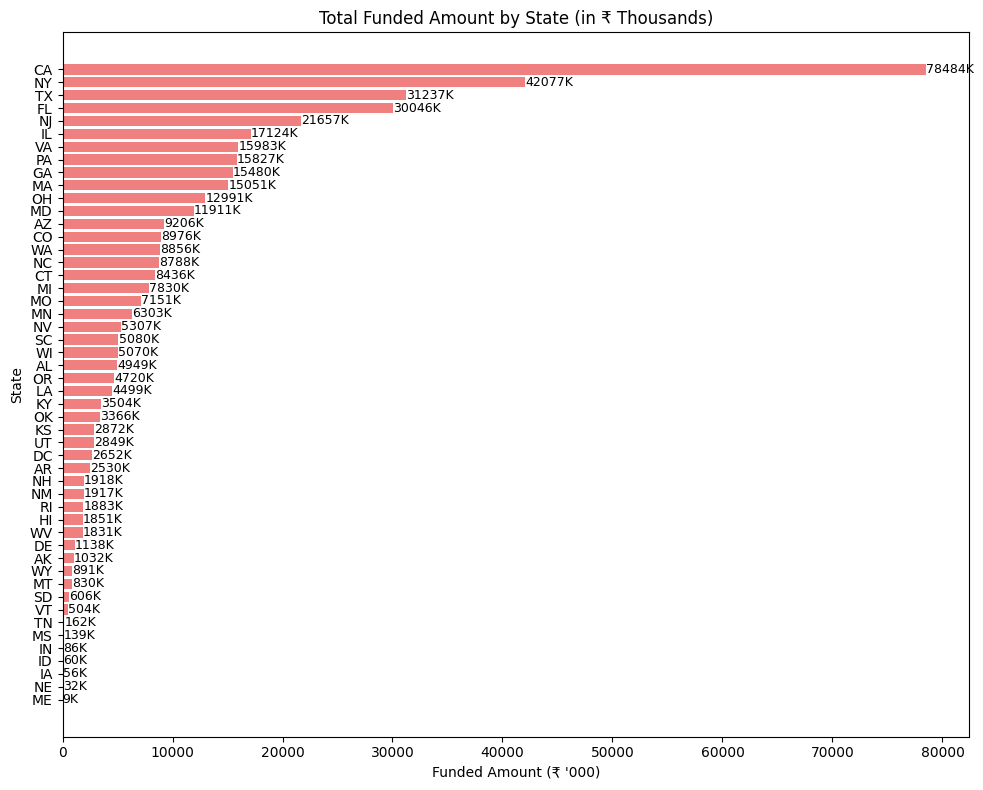

In [23]:
# Regional Analysis by State - Total Funded Amount
import matplotlib.pyplot as plt

# Group data by state and calculate total funded loan amount
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)

# Convert funded amount into thousands
state_funding_thousands = state_funding / 1000

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar chart
bars = plt.barh(
    state_funding_thousands.index,
    state_funding_thousands.values,
    color='lightcoral'
)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}K',
        va='center',
        fontsize=9
    )

# Chart title
plt.title('Total Funded Amount by State (in ₹ Thousands)')

# Axis labels
plt.xlabel("Funded Amount (₹ '000)")
plt.ylabel('State')

# Adjust layout
plt.tight_layout()

# Show chart
plt.show()

####Regional Analysis by State for Total Amount Received (Bar Chart): To identify regions with stronger repayment activity and assess regional differences in loan repayment performance.

In this analysis, I performed a regional analysis of the total amount received from loans by state to understand how loan repayments vary across different geographic regions. First, I grouped the dataset using the address_state column and calculated the total amount received from borrowers for each state by summing the total_payment column. I then sorted the results and converted the values into thousands to make the numbers easier to read and display in the visualization. After preparing the data, I created a horizontal bar chart using Matplotlib, where each bar represents a state and the length of the bar shows the total amount received from loans in that state. I also added the exact received value next to each bar to make the chart more informative and easier to interpret. This analysis helps identify which states contribute the highest loan repayments and which regions have lower repayment amounts, enabling financial institutions to understand regional repayment patterns and assess disparities in loan recovery across different states.

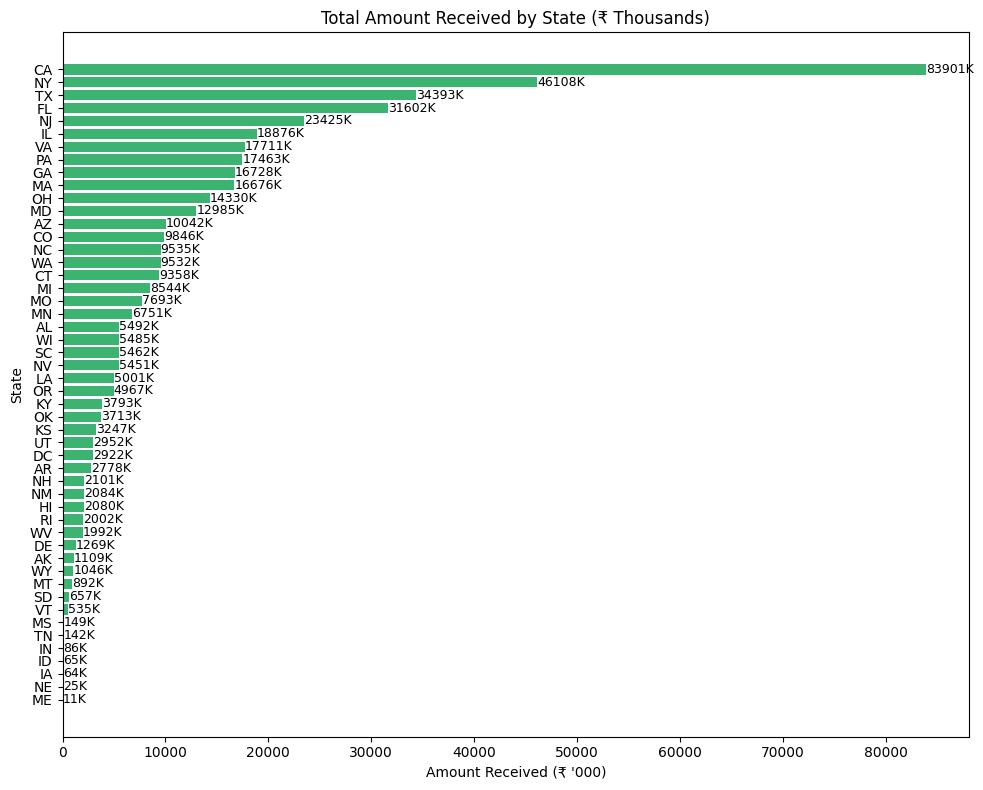

In [24]:
# Regional Analysis by State - Total Amount Received

import matplotlib.pyplot as plt

# Group data by state and calculate total amount received
state_received = (
    df.groupby('address_state')['total_payment']
      .sum()
      .sort_values(ascending=True)
)

# Convert amount into thousands
state_received_thousands = state_received / 1000

# Create chart figure
plt.figure(figsize=(10, 8))

# Horizontal bar chart
bars = plt.barh(
    state_received_thousands.index,
    state_received_thousands.values,
    color='mediumseagreen'   # different color
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Amount Received by State (₹ Thousands)')
plt.xlabel("Amount Received (₹ '000)")
plt.ylabel('State')

plt.tight_layout()
plt.show()

####Regional Analysis by State for Total Loan Applications (Bar Chart): To identify regions with significant lending activity and assess regional disparities.

In this analysis, I performed a regional analysis of loan applications by state to understand how loan demand varies across different geographic regions. First, I grouped the dataset using the address_state column and calculated the total number of loan applications for each state by counting the id column. I then sorted the results so the states appear in order based on the number of applications. After preparing the data, I created a horizontal bar chart using Matplotlib, where each bar represents a state and the length of the bar shows the total number of loan applications in that state. I also displayed the exact application count next to each bar to make the chart more informative and easier to interpret. This analysis helps identify which states have the highest loan demand and which regions have lower lending activity, allowing financial institutions to better understand regional lending patterns and disparities in loan application distribution across states.

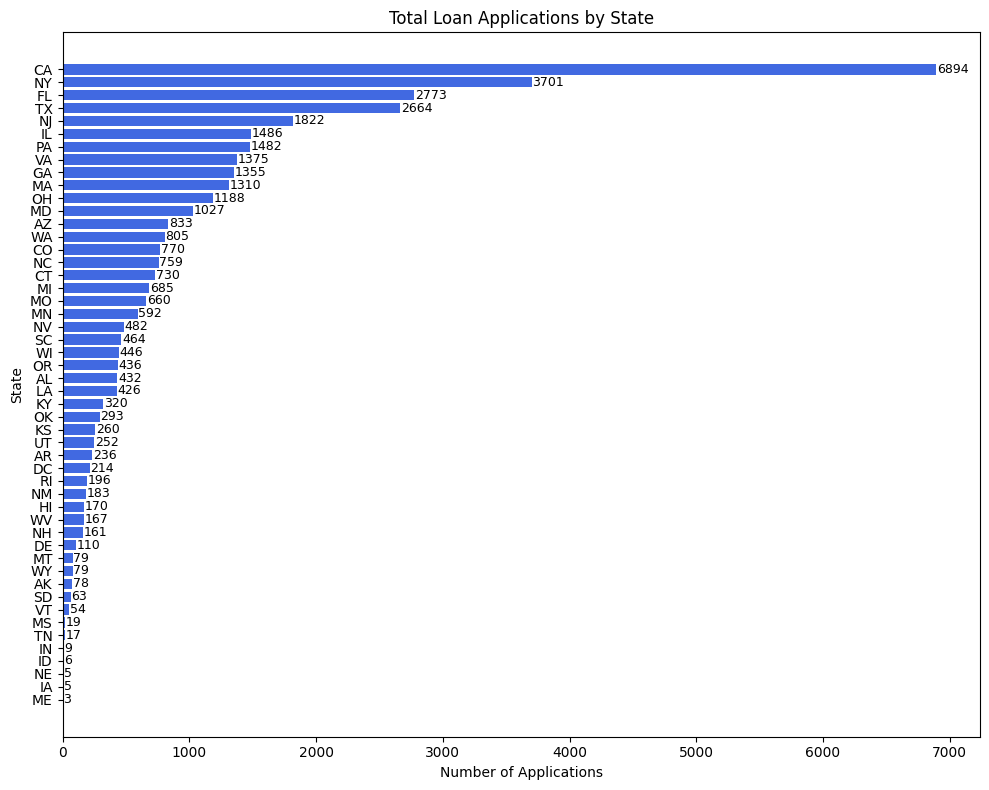

In [25]:
# Regional Analysis by State - Total Loan Applications

import matplotlib.pyplot as plt

# Count loan applications by state
state_applications = (
    df.groupby('address_state')['id']
      .count()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_applications.index,
    state_applications.values,
    color='royalblue'   # different color
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width}',
        va='center',
        fontsize=9
    )

plt.title('Total Loan Applications by State')
plt.xlabel('Number of Applications')
plt.ylabel('State')

plt.tight_layout()
plt.show()

#### Loan Term Analysis (Donut Chart):Total Funded Amount

This code analyzes the total funded loan amount based on different loan terms such as 36 months and 60 months. First, the dataset is grouped using the term column, and the total funded amount is calculated by summing the loan_amount values for each term. The values are then converted into millions to make them easier to read. After preparing the data, a donut chart is created using Matplotlib, where each segment represents a loan term and the size of the segment shows the proportion of total funding associated with that term. The chart also displays the percentage and actual funded amount for each segment, helping to clearly understand how loan funding is distributed across different loan terms.

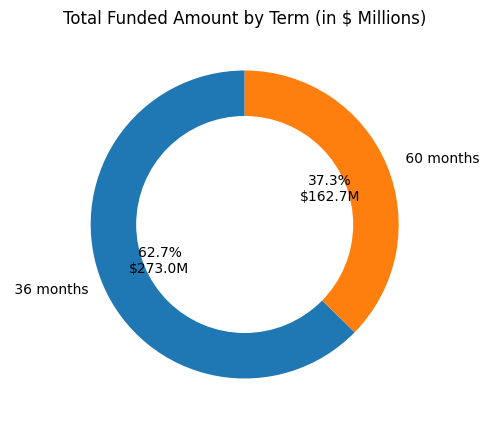

In [27]:
# Loan Term Analysis - Total Funded Amount

term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1_000_000
# Group the dataset by loan term (36 months, 60 months) and calculate the total funded loan amount
# Then divide by 1,000,000 to convert the value into millions for easier readability

plt.figure(figsize=(5,5))
# Create a new chart figure with width 5 and height 5

plt.pie(
    term_funding_millions,
    # Use the funded loan amount values as the size of each slice in the pie chart

    labels=term_funding_millions.index,
    # Display the loan term (36 months, 60 months) as labels for each slice

    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    # Show percentage of each slice and the actual funded amount in millions inside the chart

    startangle=90,
    # Start the pie chart from the top for better visualization

    wedgeprops={'width':0.4}
    # Reduce the width of slices to create a donut-style chart
)

plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
# Add a white circle in the center to convert the pie chart into a donut chart

plt.title("Total Funded Amount by Term (in $ Millions)")
# Add a title to describe the chart

plt.show()
# Display the final donut chart

##Loan Term Analysis – Total Loan Applications
This code analyzes the number of loan applications based on different loan terms such as 36 months and 60 months. The dataset is grouped by the term column, and the total loan applications are calculated by counting the id column. A donut chart is then created where each segment represents a loan term and the size of the segment shows the proportion of loan applications for each term, helping understand borrower preferences for loan duration.

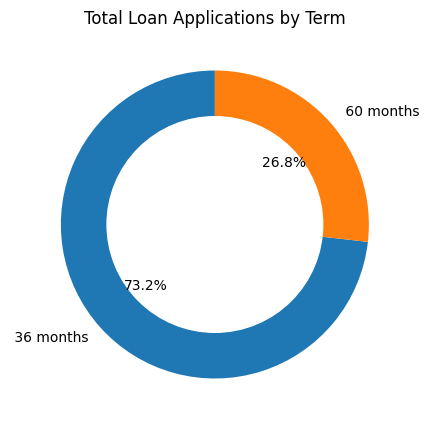

In [28]:
# Loan Term Analysis - Total Loan Applications

term_applications = df.groupby('term')['id'].count()
# Group the dataset by loan term (36 months, 60 months) and count the number of loan applications

plt.figure(figsize=(5,5))
# Create a chart figure

plt.pie(
    term_applications,
    labels=term_applications.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
# Add a white circle in the center to convert the pie chart into a donut chart

plt.title("Total Loan Applications by Term")
plt.show()

### Loan Term Analysis – Total Amount Received
This code analyzes the total amount received from loans based on different loan terms. The dataset is grouped by the term column, and the total payment received from borrowers is calculated using the total_payment column. The values are converted into millions for easier interpretation. A donut chart is created where each segment represents a loan term, and the size of each segment shows the proportion of total repayments associated with that term, helping understand repayment distribution across loan durations.

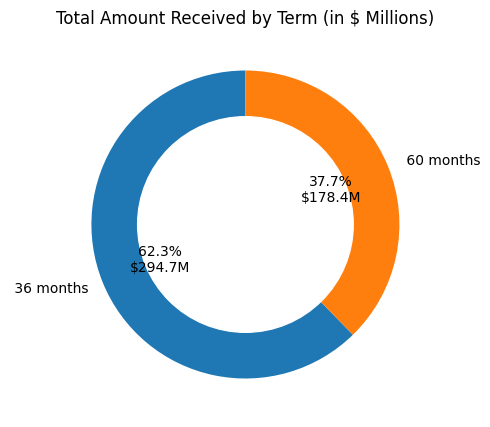

In [29]:
# Loan Term Analysis - Total Amount Received

term_received_millions = df.groupby('term')['total_payment'].sum() / 1_000_000
# Group dataset by loan term and calculate total amount received from borrowers

plt.figure(figsize=(5,5))

plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_received_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
# Convert pie chart into donut chart

plt.title("Total Amount Received by Term (in $ Millions)")
plt.show()

### 1️⃣ Employee Length Analysis – Total Loan Applications
This chart analyzes how loan applications are distributed across different employment lengths. The dataset is grouped using the emp_length column, and the total number of loan applications is calculated by counting the id column. A horizontal bar chart is created where each bar represents an employment category such as 1 year, 5 years, or 10+ years, and the bar length shows the number of loan applications. This helps identify which employment groups apply for loans more frequently and allows lenders to understand how employment history influences loan demand.

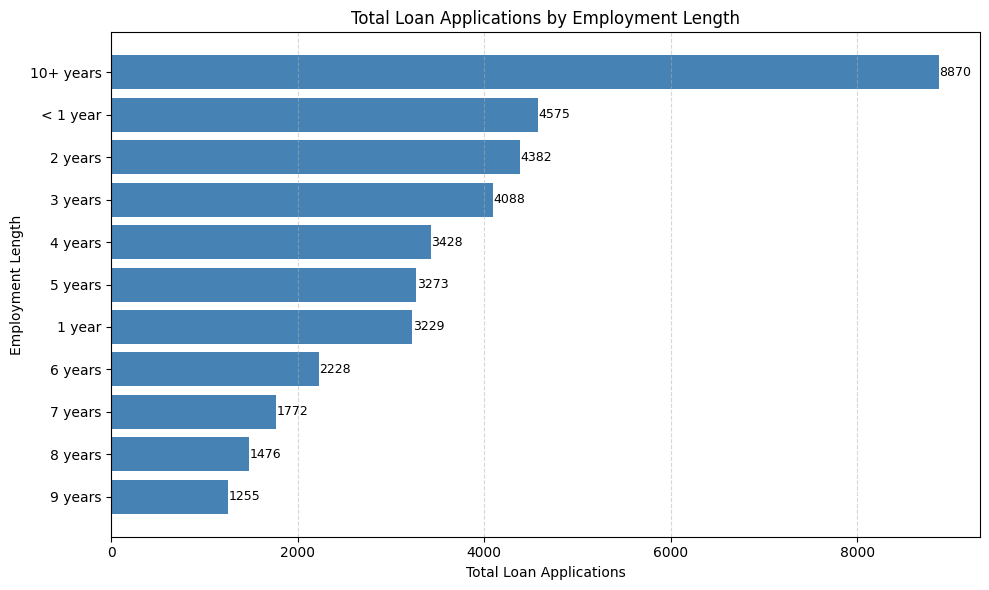

In [30]:
# Employee Length Analysis - Total Loan Applications

import matplotlib.pyplot as plt

emp_applications = df.groupby('emp_length')['id'].count().sort_values()
# Group dataset by employment length and count number of loan applications

plt.figure(figsize=(10,6))
# Create chart figure

bars = plt.barh(emp_applications.index, emp_applications.values, color='steelblue')
# Create horizontal bar chart where each bar represents employment length

for bar in bars:
    width = bar.get_width()
    # Get width of each bar (number of applications)

    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f"{width}", va='center', fontsize=9)
    # Display the application count next to each bar

plt.xlabel("Total Loan Applications")
# X-axis represents number of loan applications

plt.ylabel("Employment Length")
# Y-axis represents employment length categories

plt.title("Total Loan Applications by Employment Length")
# Chart title

plt.grid(axis='x', linestyle='--', alpha=0.5)
# Add grid lines for better readability

plt.tight_layout()
plt.show()

#### # Employee Length Analysis - Total Funded Amount

This chart examines how the total funded loan amount varies across different employment lengths. The data is grouped by the emp_length column, and the total funded amount is calculated by summing the loan_amount column. The values are converted into thousands for easier visualization. A horizontal bar chart is then created where each bar represents an employment category and shows the total amount of loans funded for that group. This helps financial institutions understand which employment groups receive higher loan funding.

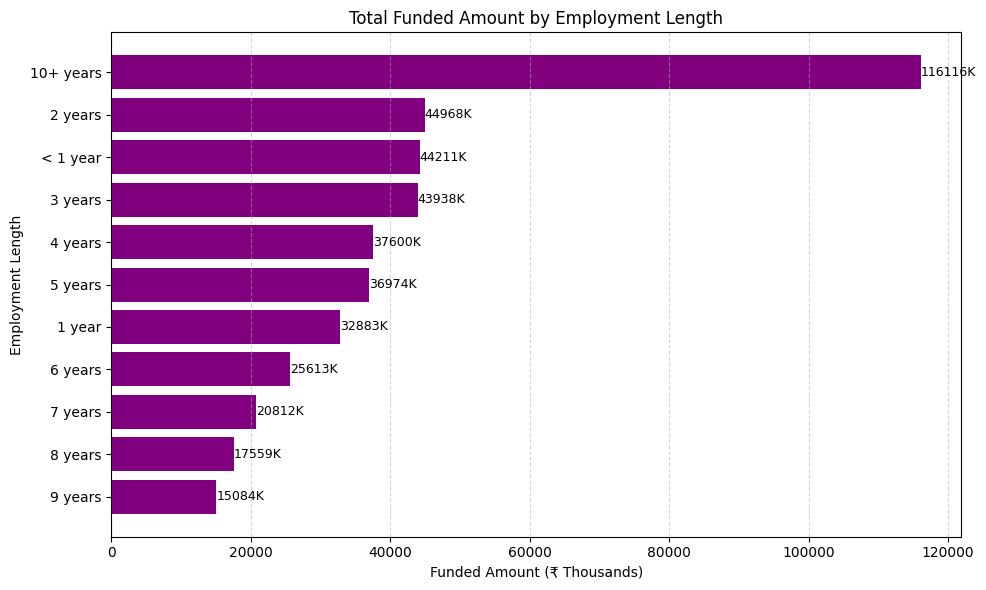

In [31]:
# Employee Length Analysis - Total Funded Amount

emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000
# Group dataset by employment length and calculate total funded loan amount
# Convert values into thousands for easier readability

plt.figure(figsize=(10,6))
# Create chart figure

bars = plt.barh(emp_funding.index, emp_funding.values, color='purple')
# Create horizontal bar chart

for bar in bars:
    width = bar.get_width()
    # Get funded amount value

    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K", va='center', fontsize=9)
    # Display funded amount value beside each bar

plt.xlabel("Funded Amount (₹ Thousands)")
# X-axis shows funded loan amount

plt.ylabel("Employment Length")
# Y-axis shows employment categories

plt.title("Total Funded Amount by Employment Length")
# Chart title

plt.grid(axis='x', linestyle='--', alpha=0.5)
# Add grid lines

plt.tight_layout()
plt.show()

#### Employee Length Analysis - Total Amount Received

This chart analyzes the total repayment amount received from borrowers across different employment lengths. The dataset is grouped by emp_length, and the total repayment amount is calculated by summing the total_payment column. The values are again converted into thousands for better readability. The horizontal bar chart shows how repayment contributions vary among employment groups, helping lenders evaluate repayment patterns based on borrowers’ employment history.

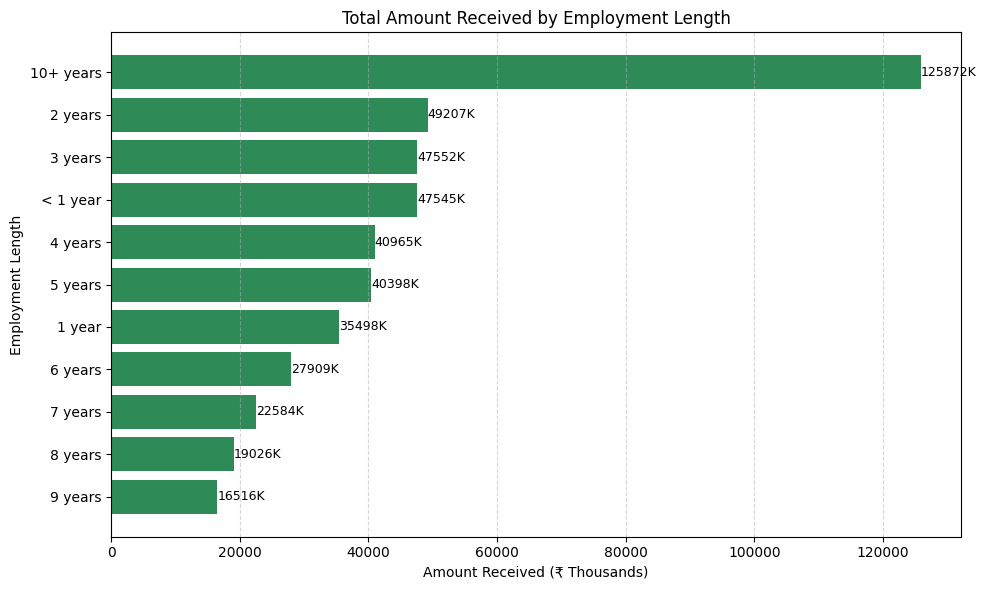

In [32]:
# Employee Length Analysis - Total Amount Received

emp_received = df.groupby('emp_length')['total_payment'].sum().sort_values() / 1000
# Group dataset by employment length and calculate total amount received from borrowers
# Convert values into thousands

plt.figure(figsize=(10,6))

bars = plt.barh(emp_received.index, emp_received.values, color='seagreen')
# Horizontal bar chart showing total amount received

for bar in bars:
    width = bar.get_width()

    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K", va='center', fontsize=9)
    # Display received amount value

plt.xlabel("Amount Received (₹ Thousands)")
# X-axis shows repayment amount

plt.ylabel("Employment Length")
# Y-axis shows employment categories

plt.title("Total Amount Received by Employment Length")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## # Loan Purpose Breakdown - Total Loan Applications

This chart analyzes how loan applications are distributed based on the purpose of the loan. The dataset is grouped using the purpose column, and the total number of applications is calculated by counting the id column. Each bar in the chart represents a loan purpose such as debt consolidation, credit card refinancing, home improvement, or small business. The length of each bar shows the number of applications submitted for that purpose. This visualization helps identify the most common reasons borrowers apply for loans, enabling lenders to understand borrower needs and demand patterns.



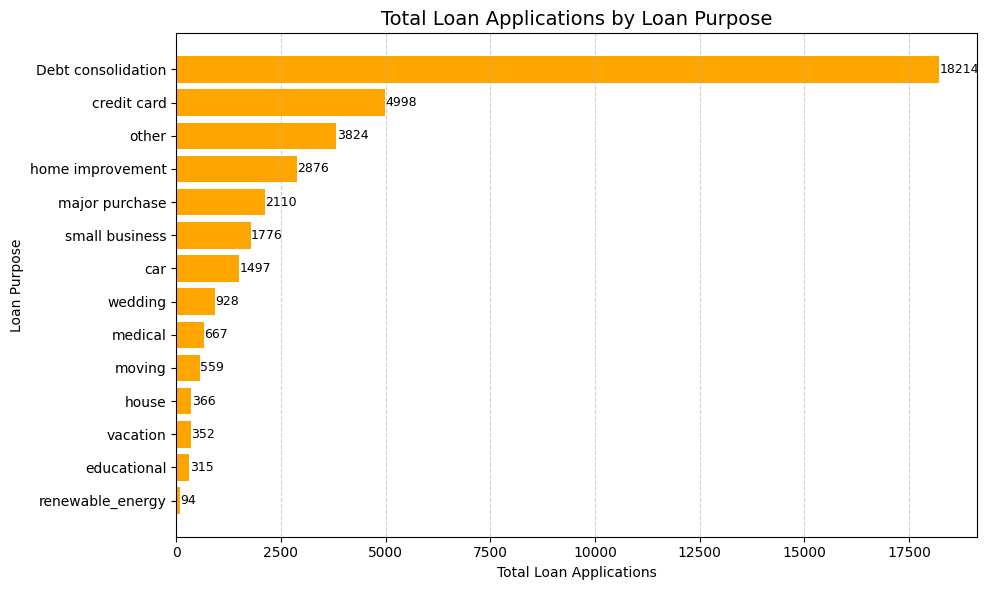

In [33]:
# Loan Purpose Breakdown - Total Loan Applications

import matplotlib.pyplot as plt

purpose_applications = df.groupby('purpose')['id'].count().sort_values()
# Group dataset by loan purpose and count total loan applications

plt.figure(figsize=(10,6))
# Create chart figure with width 10 and height 6

bars = plt.barh(purpose_applications.index, purpose_applications.values, color='orange')
# Create horizontal bar chart where each bar represents a loan purpose

for bar in bars:
    width = bar.get_width()
    # Get number of applications for that purpose

    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f"{width}", va='center', fontsize=9)
    # Display application count next to each bar

plt.title("Total Loan Applications by Loan Purpose", fontsize=14)
# Chart title

plt.xlabel("Total Loan Applications")
# X-axis shows number of applications

plt.ylabel("Loan Purpose")
# Y-axis shows loan purpose categories

plt.grid(axis='x', linestyle='--', alpha=0.6)
# Add grid lines for readability

plt.tight_layout()
# Adjust layout so labels don't overlap

plt.show()
# Display chart

#### Loan Purpose Breakdown - Total Funded Amount

This chart shows how the total funded loan amount is distributed across different loan purposes. The data is grouped by the purpose column, and the loan_amount values are summed to calculate the total funding for each purpose. The amounts are converted into millions to make the chart easier to interpret. Each bar represents a loan purpose, and its length shows the total amount of money funded for that category. This analysis helps financial institutions identify which loan purposes receive the highest funding, helping them allocate lending resources more effectively.



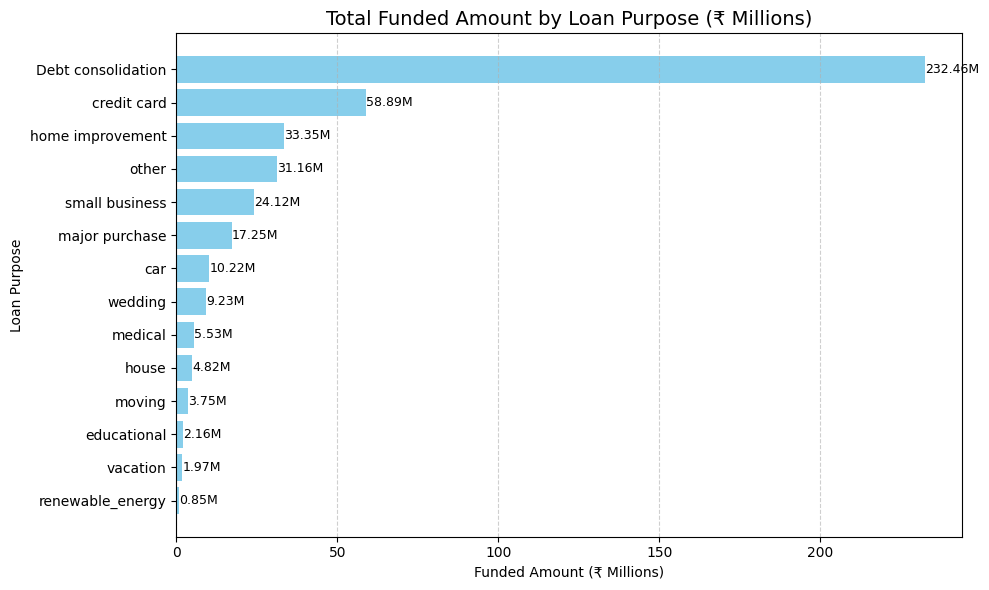

In [34]:
# Loan Purpose Breakdown - Total Funded Amount

purpose_funding_millions = df.groupby('purpose')['loan_amount'].sum().sort_values() / 1000000
# Group dataset by loan purpose and calculate total funded amount
# Convert values into millions

plt.figure(figsize=(10,6))

bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')
# Horizontal bar chart showing funded loan amount by purpose

for bar in bars:
    width = bar.get_width()

    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}M", va='center', fontsize=9)
    # Display funded amount value beside each bar

plt.title("Total Funded Amount by Loan Purpose (₹ Millions)", fontsize=14)
# Chart title

plt.xlabel("Funded Amount (₹ Millions)")
# X-axis shows funded loan amount

plt.ylabel("Loan Purpose")
# Y-axis shows loan purpose categories

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Loan Purpose Breakdown - Total Amount Received

This chart examines the total repayment amount received from borrowers for different loan purposes. The dataset is grouped by loan purpose, and the total_payment column is summed to calculate the total repayment received for each category. The values are converted into millions for better visualization. Each bar represents a loan purpose, and the bar length shows the total repayment amount. This analysis helps lenders understand which loan purposes generate the highest repayments, providing insights into borrower repayment behavior and loan performance across different financing needs.

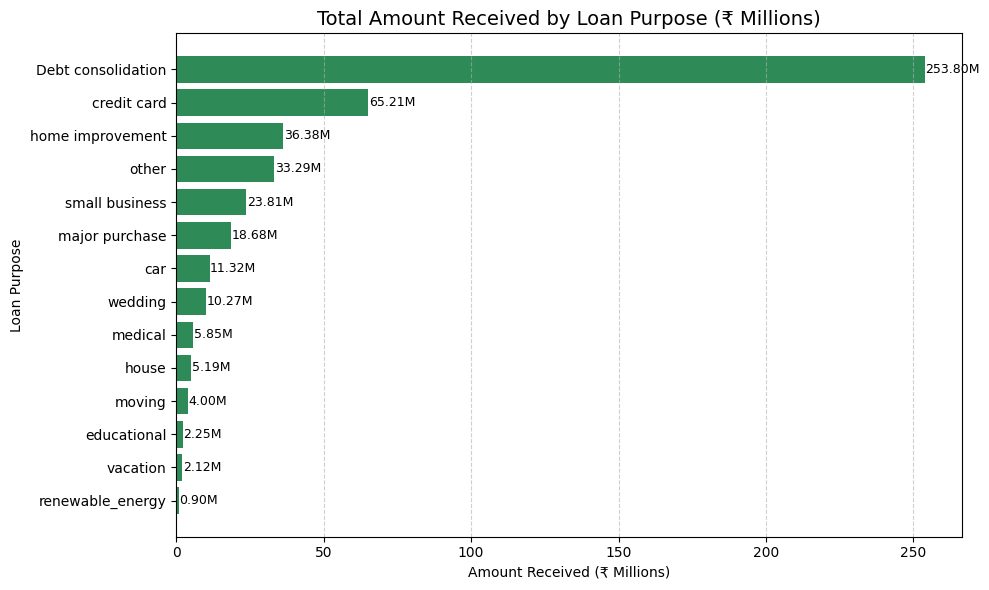

In [35]:
# Loan Purpose Breakdown - Total Amount Received

purpose_received_millions = df.groupby('purpose')['total_payment'].sum().sort_values() / 1000000
# Group dataset by loan purpose and calculate total amount received
# Convert repayment values into millions

plt.figure(figsize=(10,6))

bars = plt.barh(purpose_received_millions.index, purpose_received_millions.values, color='seagreen')
# Create horizontal bar chart

for bar in bars:
    width = bar.get_width()

    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}M", va='center', fontsize=9)
    # Display repayment amount beside each bar

plt.title("Total Amount Received by Loan Purpose (₹ Millions)", fontsize=14)

plt.xlabel("Amount Received (₹ Millions)")
plt.ylabel("Loan Purpose")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Home Ownership Analysis – Total Loan Applications (Tree Map)
This analysis examines how loan applications vary across different home ownership categories such as rent, own, or mortgage. The dataset is grouped using the home_ownership column, and the total number of loan applications is calculated by counting the id column. A tree map visualization is created where each block represents a home ownership category, and the size of the block indicates the number of loan applications. This helps identify which housing groups apply for loans more frequently and provides insights into borrower demographics.

In [36]:
# Home Ownership Analysis - Total Loan Applications

import plotly.express as px

home_applications = df.groupby('home_ownership')['id'].count().reset_index()
# Group dataset by home ownership category (own, rent, mortgage, etc.)
# Count total loan applications using the id column

fig = px.treemap(
    home_applications,
    path=['home_ownership'],      # Tree map hierarchy based on home ownership categories
    values='id',                  # Size of each block represents number of applications
    color='id',                   # Color intensity based on application count
    color_continuous_scale='Blues',
    title='Total Loan Applications by Home Ownership'
)

fig.show()
# Display the tree map

###Home Ownership Analysis – Total Funded Amount (Tree Map)
This chart analyzes how loan funding is distributed among borrowers with different home ownership statuses. The data is grouped by the home_ownership column, and the loan_amount values are summed to calculate the total funded amount for each category. The values are converted into millions for easier interpretation. In the tree map, the size and color intensity of each block represent the funded loan amount, helping lenders understand which home ownership groups receive the largest loan funding.

In [38]:
# Home Ownership Analysis - Total Funded Amount

home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
# Group dataset by home ownership and calculate total funded loan amount

home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000
# Convert loan amount into millions for better readability

fig = px.treemap(
    home_funding,
    path=['home_ownership'],         # Categories of home ownership
    values='loan_amount_millions',   # Block size represents funded loan amount
    color='loan_amount_millions',    # Color intensity based on funded amount
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()

##Home Ownership Analysis – Total Amount Received (Tree Map)
Total Amount Received by Home Ownership

This visualization examines the total repayment amount received from borrowers across different home ownership categories. The dataset is grouped by home_ownership, and the total_payment column is summed to calculate the total repayment amount for each category. The values are converted into millions for better readability. The tree map shows the distribution of repayments among different home ownership groups, helping lenders evaluate repayment behavior and financial performance across borrower segments.

In [37]:
# Home Ownership Analysis - Total Amount Received

home_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()
# Group dataset by home ownership category and calculate total repayment received

home_received['received_millions'] = home_received['total_payment'] / 1_000_000
# Convert repayment amount into millions

fig = px.treemap(
    home_received,
    path=['home_ownership'],
    values='received_millions',      # Block size shows repayment amount
    color='received_millions',       # Color intensity based on repayment value
    color_continuous_scale='Greens',
    title='Total Amount Received by Home Ownership (₹ Millions)'
)

fig.show()

#### In this project, a comprehensive analysis of loan data was performed to understand lending patterns, borrower behavior, and overall loan performance. Multiple visualizations were created to analyze key metrics such as Total Loan Applications, Total Funded Amount, and Total Amount Received across different dimensions including time, region, loan term, employment length, loan purpose, and home ownership status.

The monthly trend analysis helped identify patterns in lending activity over time and provided insights into seasonal trends in loan applications and funding. The regional analysis by state highlighted geographical disparities in lending activity, allowing identification of regions with higher loan demand and funding distribution.

The loan term analysis revealed how loans are distributed between different loan durations such as 36 months and 60 months, helping understand borrower preferences for loan repayment periods. The employment length analysis showed how borrowers’ work experience influences loan applications and funding amounts.

The loan purpose breakdown provided insights into the primary reasons borrowers seek financing, such as debt consolidation, credit card refinancing, and home improvement, helping lenders understand customer needs. Additionally, the home ownership analysis demonstrated how different housing statuses such as rent, mortgage, and own impact loan application behavior and funding distribution.

Overall, the analysis provides valuable insights into lending trends, borrower characteristics, and loan performance, enabling financial institutions to make data-driven decisions, improve risk assessment, and optimize lending strategies. These insights can support better portfolio management, targeted lending policies, and strategic business planning.